In [1]:

%load_ext autoreload
%autoreload 2
from mGST.low_level_jit import cost_function_jax_mps
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, create_4q_gst_config, get_compressed_perturbed_rep_from_mgst
from mGST.trust_region import run_riemannian_optimization
from mGST.typing import TrustRegionOptions, GradientDescentOptions, OperatorSchedule
from mGST.visualization import plot_cost_function, plot_alternating_optimization

import jax.numpy as jnp

from iqm.qiskit_iqm import IQMProvider

import os
os.environ[
    "IQM_TOKEN"
] = "UWcEU3ZP7mxzs7XBs4Lit7sht39u9wmoX/cQ6p3HsiMBmb9y++B244T70dk7QacX"

iqm_server_url = "https://cocos.resonance.meetiqm.com/garnet"
provider = IQMProvider(iqm_server_url)
backend = provider.get_backend()

/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/iqm/iqm_client/iqm_client.py:135: UserWarning: Your IQM Client version 20.17 was built for a different version of IQM Server. You might encounter issues. For the best experience, consider using a version of IQM Client that satisfies 30.1.0 <= iqm-client < 31.0.
  warnings.warn(version_incompatibility_msg)


In [2]:
500/23 * 500 # max number of gates per batch (in theory)

10869.565217391304

In [3]:
22 * 500

11000

In [ ]:
# Changed the default timeout in iqm_client.py to 9000 seconds
from iqm.iqm_client.iqm_client import DEFAULT_TIMEOUT_SECONDS
DEFAULT_TIMEOUT_SECONDS

9000

In [6]:
dim = 2**4
kraus_rank = 16
state_rank = dim
povm_rank = dim
max_gates_per_batch = 10000 # limit for real backend - computed using the fact that we are allowed 500 circuits per job and each circuit has at most 22 gates
Q4_GST = create_4q_gst_config(kraus_rank=kraus_rank, max_gates_per_batch=max_gates_per_batch)

In [53]:
import jax
jax.grad(jnp.abs)(0.0)

Array(1., dtype=float64, weak_type=True)

In [7]:
kraus_tensor_mgst, kraus_mgst, povm_mgst, state_mgst, prob_matrix, indices_list = get_full_mgst_parameters_from_configuration(
    Q4_GST, backend, only_jax_variables=True
)

2025-10-08 16:17:56,496 - iqm.benchmarks.logging_config - INFO - Now generating 2000 random GST circuits...
2025-10-08 16:17:57,380 - iqm.benchmarks.logging_config - INFO - Will transpile all 2000 circuits according to fixed physical layout
2025-10-08 16:17:57,380 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQM Backend with optimization level 0, sabre routing method all circuits
2025-10-08 16:18:00,842 - iqm.benchmarks.logging_config - INFO - Submitting batch with 2000 circuits corresponding to qubits [0, 1, 3, 4]
2025-10-08 16:18:00,862 - iqm.benchmarks.logging_config - INFO - max_gates_per_batch restriction: submitting subbatch #1 with 463 circuits corresponding to qubits [0, 1, 3, 4]
/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/iqm/qiskit_iqm/iqm_provider.py:170: UserWarning: Unknown backend option(s): {'calibration_set_id'}
  warnings.warn(f'Unknown backend option(s): {unknown_options}')
2025-10-08 16:18:02,658 - iqm.benchmarks.

In [8]:
kraus_tensor_mgst.shape, povm_mgst.shape, state_mgst.shape

((9, 16, 16, 16), (16, 256), (256,))

In [9]:
# Kraus is already perturbed
kraus_tensor_init_jax = jnp.array(kraus_tensor_mgst)
povm_psd_init_jax, state_psd_init_jax = get_compressed_perturbed_rep_from_mgst(povm_mgst, state_mgst)

init_operators_jax = {
    "kraus_tensor_init": kraus_tensor_init_jax,
    "povm_psd_init": povm_psd_init_jax,
    "state_psd_init": state_psd_init_jax,
}

cost_fn_kwargs = {
    "indices_list": indices_list,
    "prob_matrix": prob_matrix,
    "jit": True,
}

initial_cost_value = cost_function_jax_mps(kraus_tensor_init_jax, povm_psd_init_jax, state_psd_init_jax, **cost_fn_kwargs)
print("Initial cost value:", initial_cost_value)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 242 the new count changed to: 5
at iteration 393 the new count changed to: 6
at iteration 544 the new count changed to: 7
at iteration 696 the new count changed to: 8
at iteration 848 the new count changed to: 9
at iteration 1000 the new count changed to: 10
at iteration 1166 the new count changed to: 11
at iteration 1332 the new count changed to: 12
at iteration 1499 the new count changed to: 13
at iteration 1666 the new count changed to: 14
at iteration 1833 the new count changed to: 15
Initial cost value: 0.0001498644321727048


# Optimization

In [15]:
num_iterations_all_tr = 2
tr_schedule_verbose = OperatorSchedule.default(num_iterations_all_tr, TrustRegionOptions(num_iterations=10, verbose=True, verbose_cg=True, num_iterations_cg=5))

tr_schedule_state = OperatorSchedule.default(num_iterations_all_tr, TrustRegionOptions(num_iterations=10, verbose=True, verbose_cg=True, num_iterations_cg=5, tol_grad=1e-8))

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_state
}

In [16]:
optimized_operators_all_tr, cost_fn_history_all_tr = run_riemannian_optimization(
    **init_operators_jax,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=num_iterations_all_tr,
    optimization_schedule=optimization_schedule_all_tr,
    verbose=True,
    save_intermediate_cost_values=True, # To plot all intermediate values of each operator
)

🔰 Starting Riemannian Optimization 🔰 
 with optimization schedule: 
kraus: Schedule:
  [0-1]: TrustRegionOptions
povm: Schedule:
  [0-1]: TrustRegionOptions
state: Schedule:
  [0-1]: TrustRegionOptions
TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.498644e-04. |r∇f(x)|: 1.246682e-04. Radius: 1.00e-01
TCG finished after: 2/5 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 1.432572e-04. |r∇f(x)|: 3.288798e-05. Radius: 2.00e-01
TCG finished after: 5/5 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 2. f(x): 1.419602e-04. |r∇f(x)|: 1.370493e-05. Radius: 2.00e-01
TCG finished after: 5/5 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 3. f(x): 1.417338e-04. |r∇f(x)|: 6.392464e-06. Radius: 2.00e-01
TCG finished after: 5/5 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 4. 

In [ ]:
data_operator_map = [
    ("povm", 10), ("kraus", 10), ("state", 3), ("povm", 10), ("kraus", 10), ("state", 2),
] # assume the first data point is the un-optimized one

# length of the sequences defined by data operator map
length_of_sequences = sum([length for _, length in data_operator_map])

print("Length of sequences:", length_of_sequences)
print(len(cost_fn_history_all_tr))

Length of sequences: 45
46


In [29]:
num_iterations = 10
gds_schedule = OperatorSchedule.default(num_iterations, GradientDescentOptions(ls_max_iter=20))
gds_schedule_kraus = OperatorSchedule.default(num_iterations, GradientDescentOptions(ls_max_iter=200))

optimization_schedule_all_gds = {
    "kraus": gds_schedule_kraus,
    "povm": gds_schedule,
    "state": gds_schedule
}

In [30]:
optimized_operators_all_gds, cost_fn_history_all_gds = run_riemannian_optimization(
    **init_operators_jax,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=num_iterations,
    optimization_schedule=optimization_schedule_all_gds,
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 with optimization schedule: 
kraus: Schedule:
  [0-9]: GradientDescentOptions
povm: Schedule:
  [0-9]: GradientDescentOptions
state: Schedule:
  [0-9]: GradientDescentOptions
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
GDS started for operator: state 🚀.
Using JAX power
🏁 Iteration: 1/10. f(x): 1.311999e-04.
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
GDS started for operator: state 🚀.
Using JAX power
🏁 Iteration: 2/10. f(x): 1.227648e-04.
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
GDS started for operator: state 🚀.
Using JAX power
🏁 Iteration: 3/10. f(x): 1.171176e-04.
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
GDS started for operator: state 🚀.
Using JAX power
🏁 Iteration: 4/10. f(x): 1.126981e-04.
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
G

In [36]:
cost_fn_history_all_gds[-2:]

[9.4335739210399e-05, 9.431802824443559e-05]

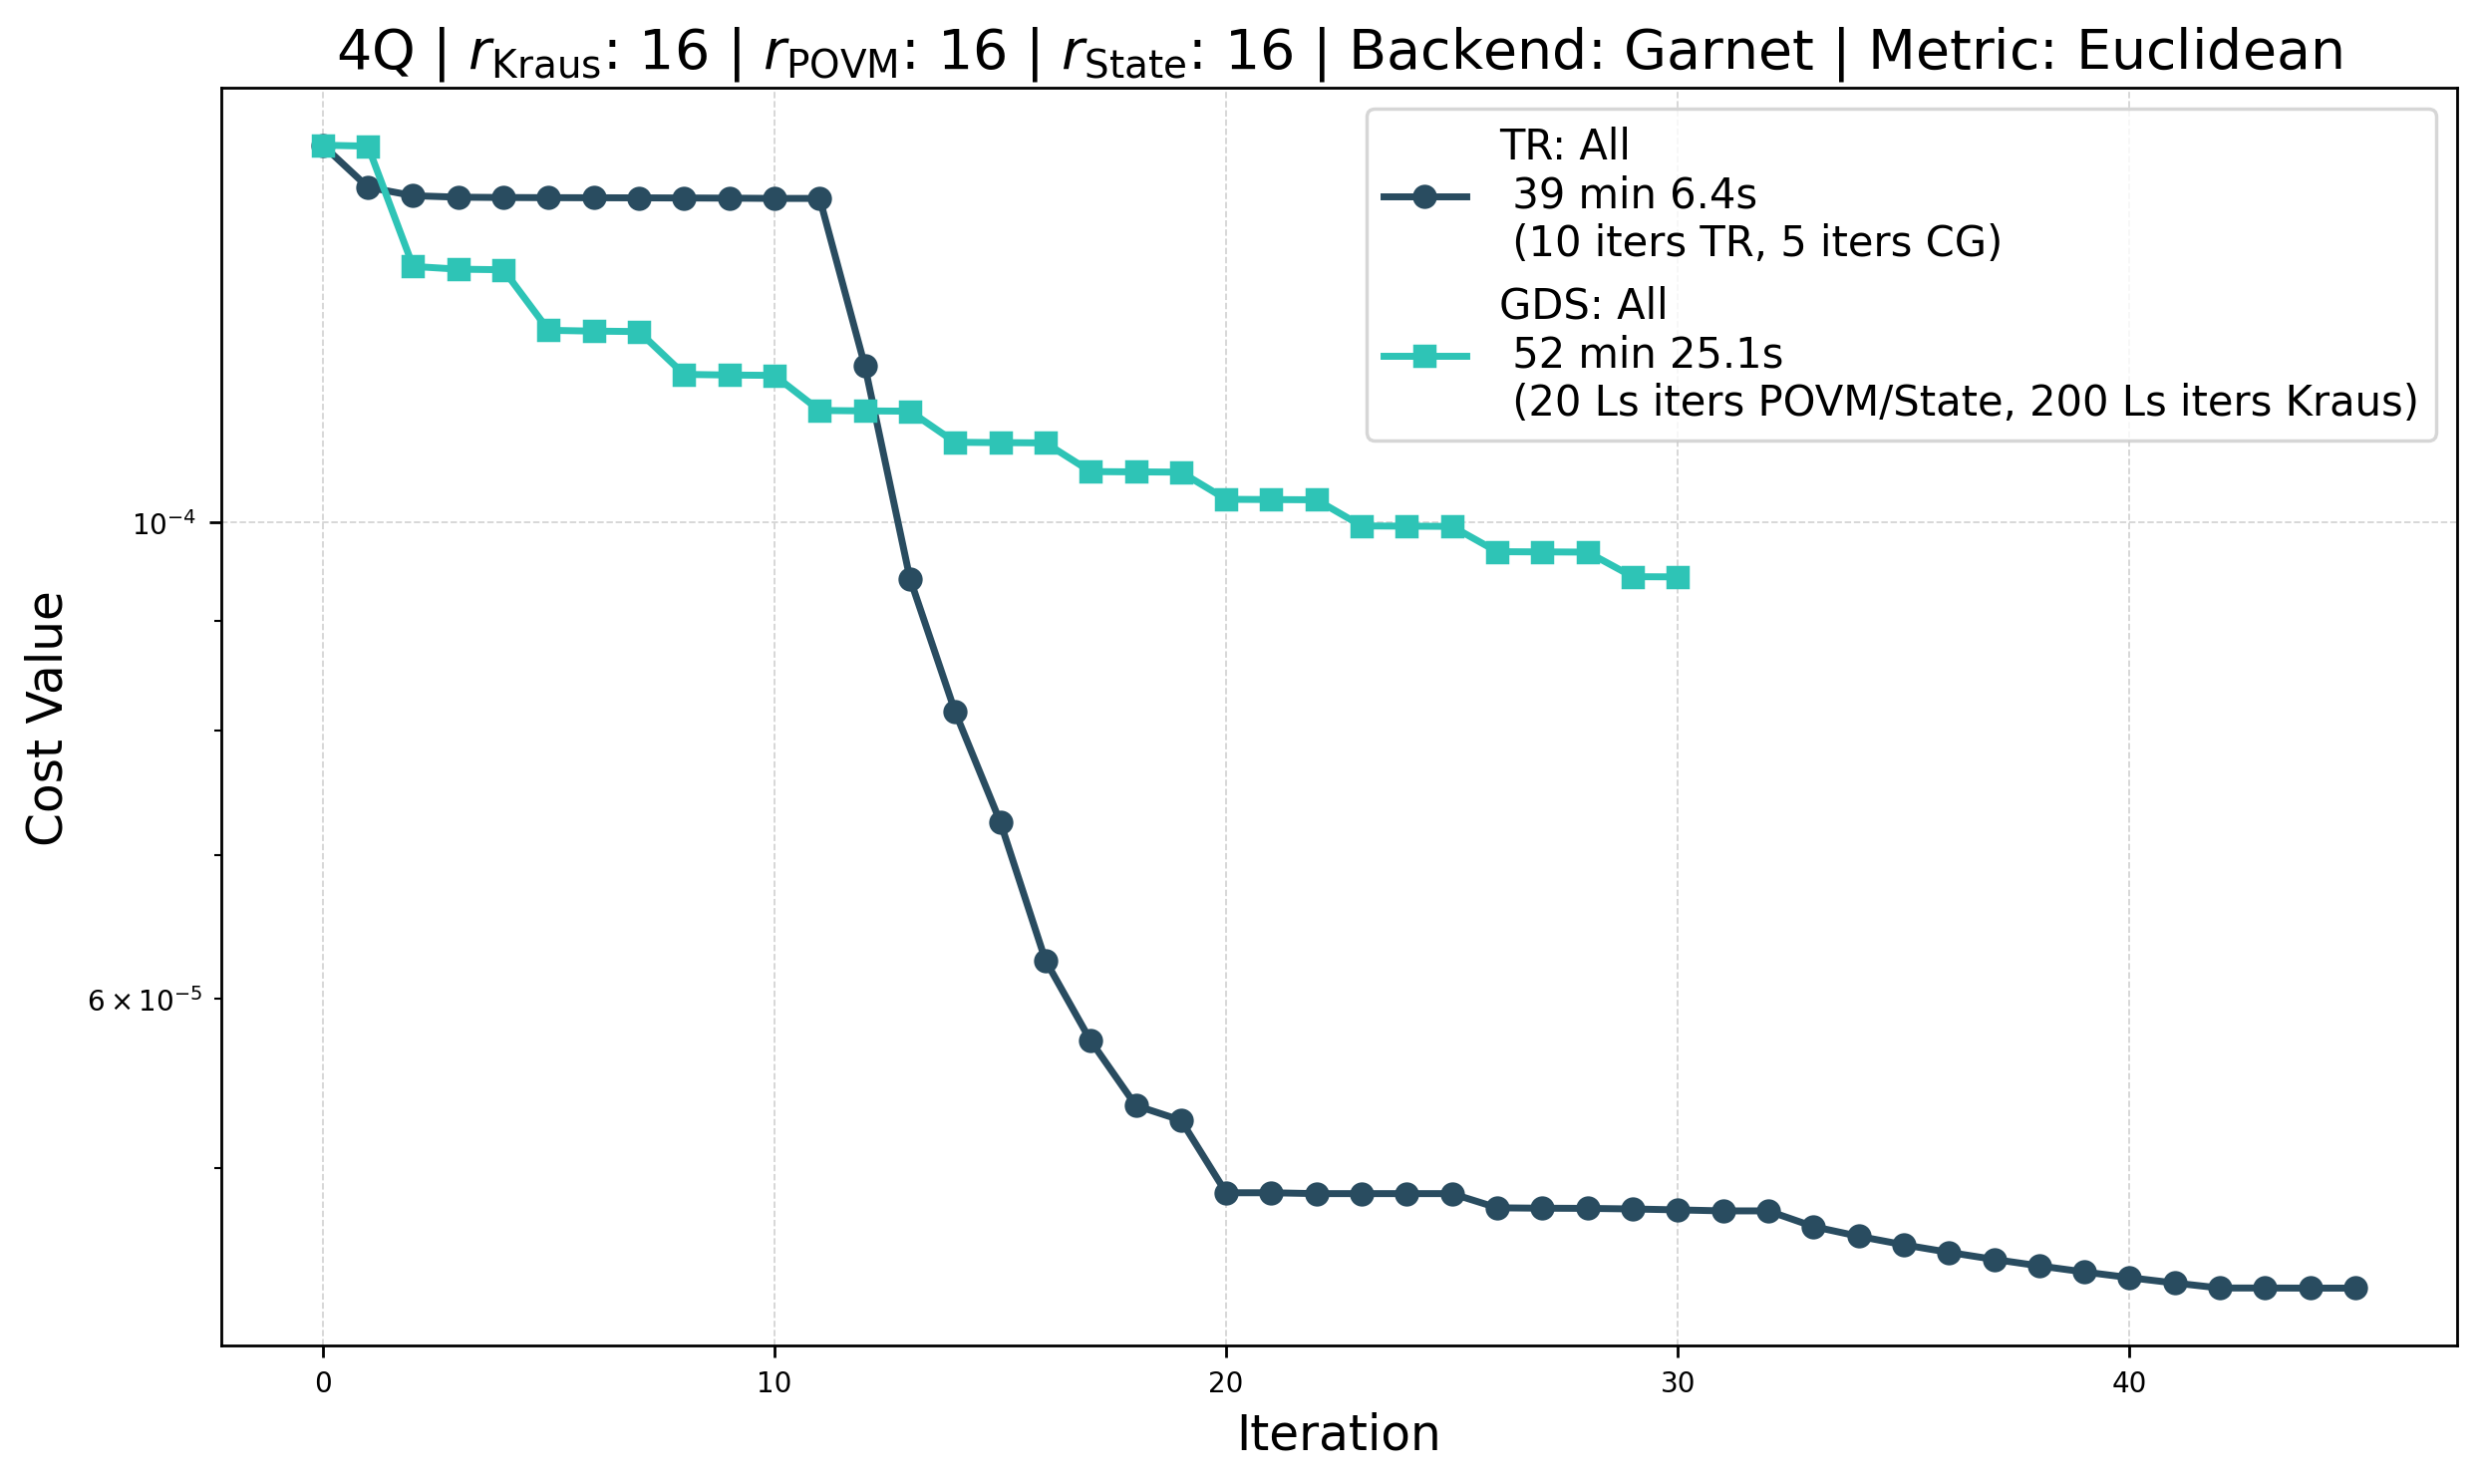

In [49]:
cost_fn_history_all_gds_appended = [initial_cost_value] + cost_fn_history_all_gds

cost_fn_lists = [
    cost_fn_history_all_tr,
    cost_fn_history_all_gds_appended,
]

labels = [
    "TR: All \n 39 min 6.4s \n (10 iters TR, 5 iters CG)",
    "GDS: All \n 52 min 25.1s \n (20 Ls iters POVM/State, 200 Ls iters Kraus)",
]

backend_name = "Garnet"
title = rf"4Q | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Backend: {backend_name} | Metric: Euclidean"

plot_cost_function(cost_fn_lists, title=title, labels=labels)

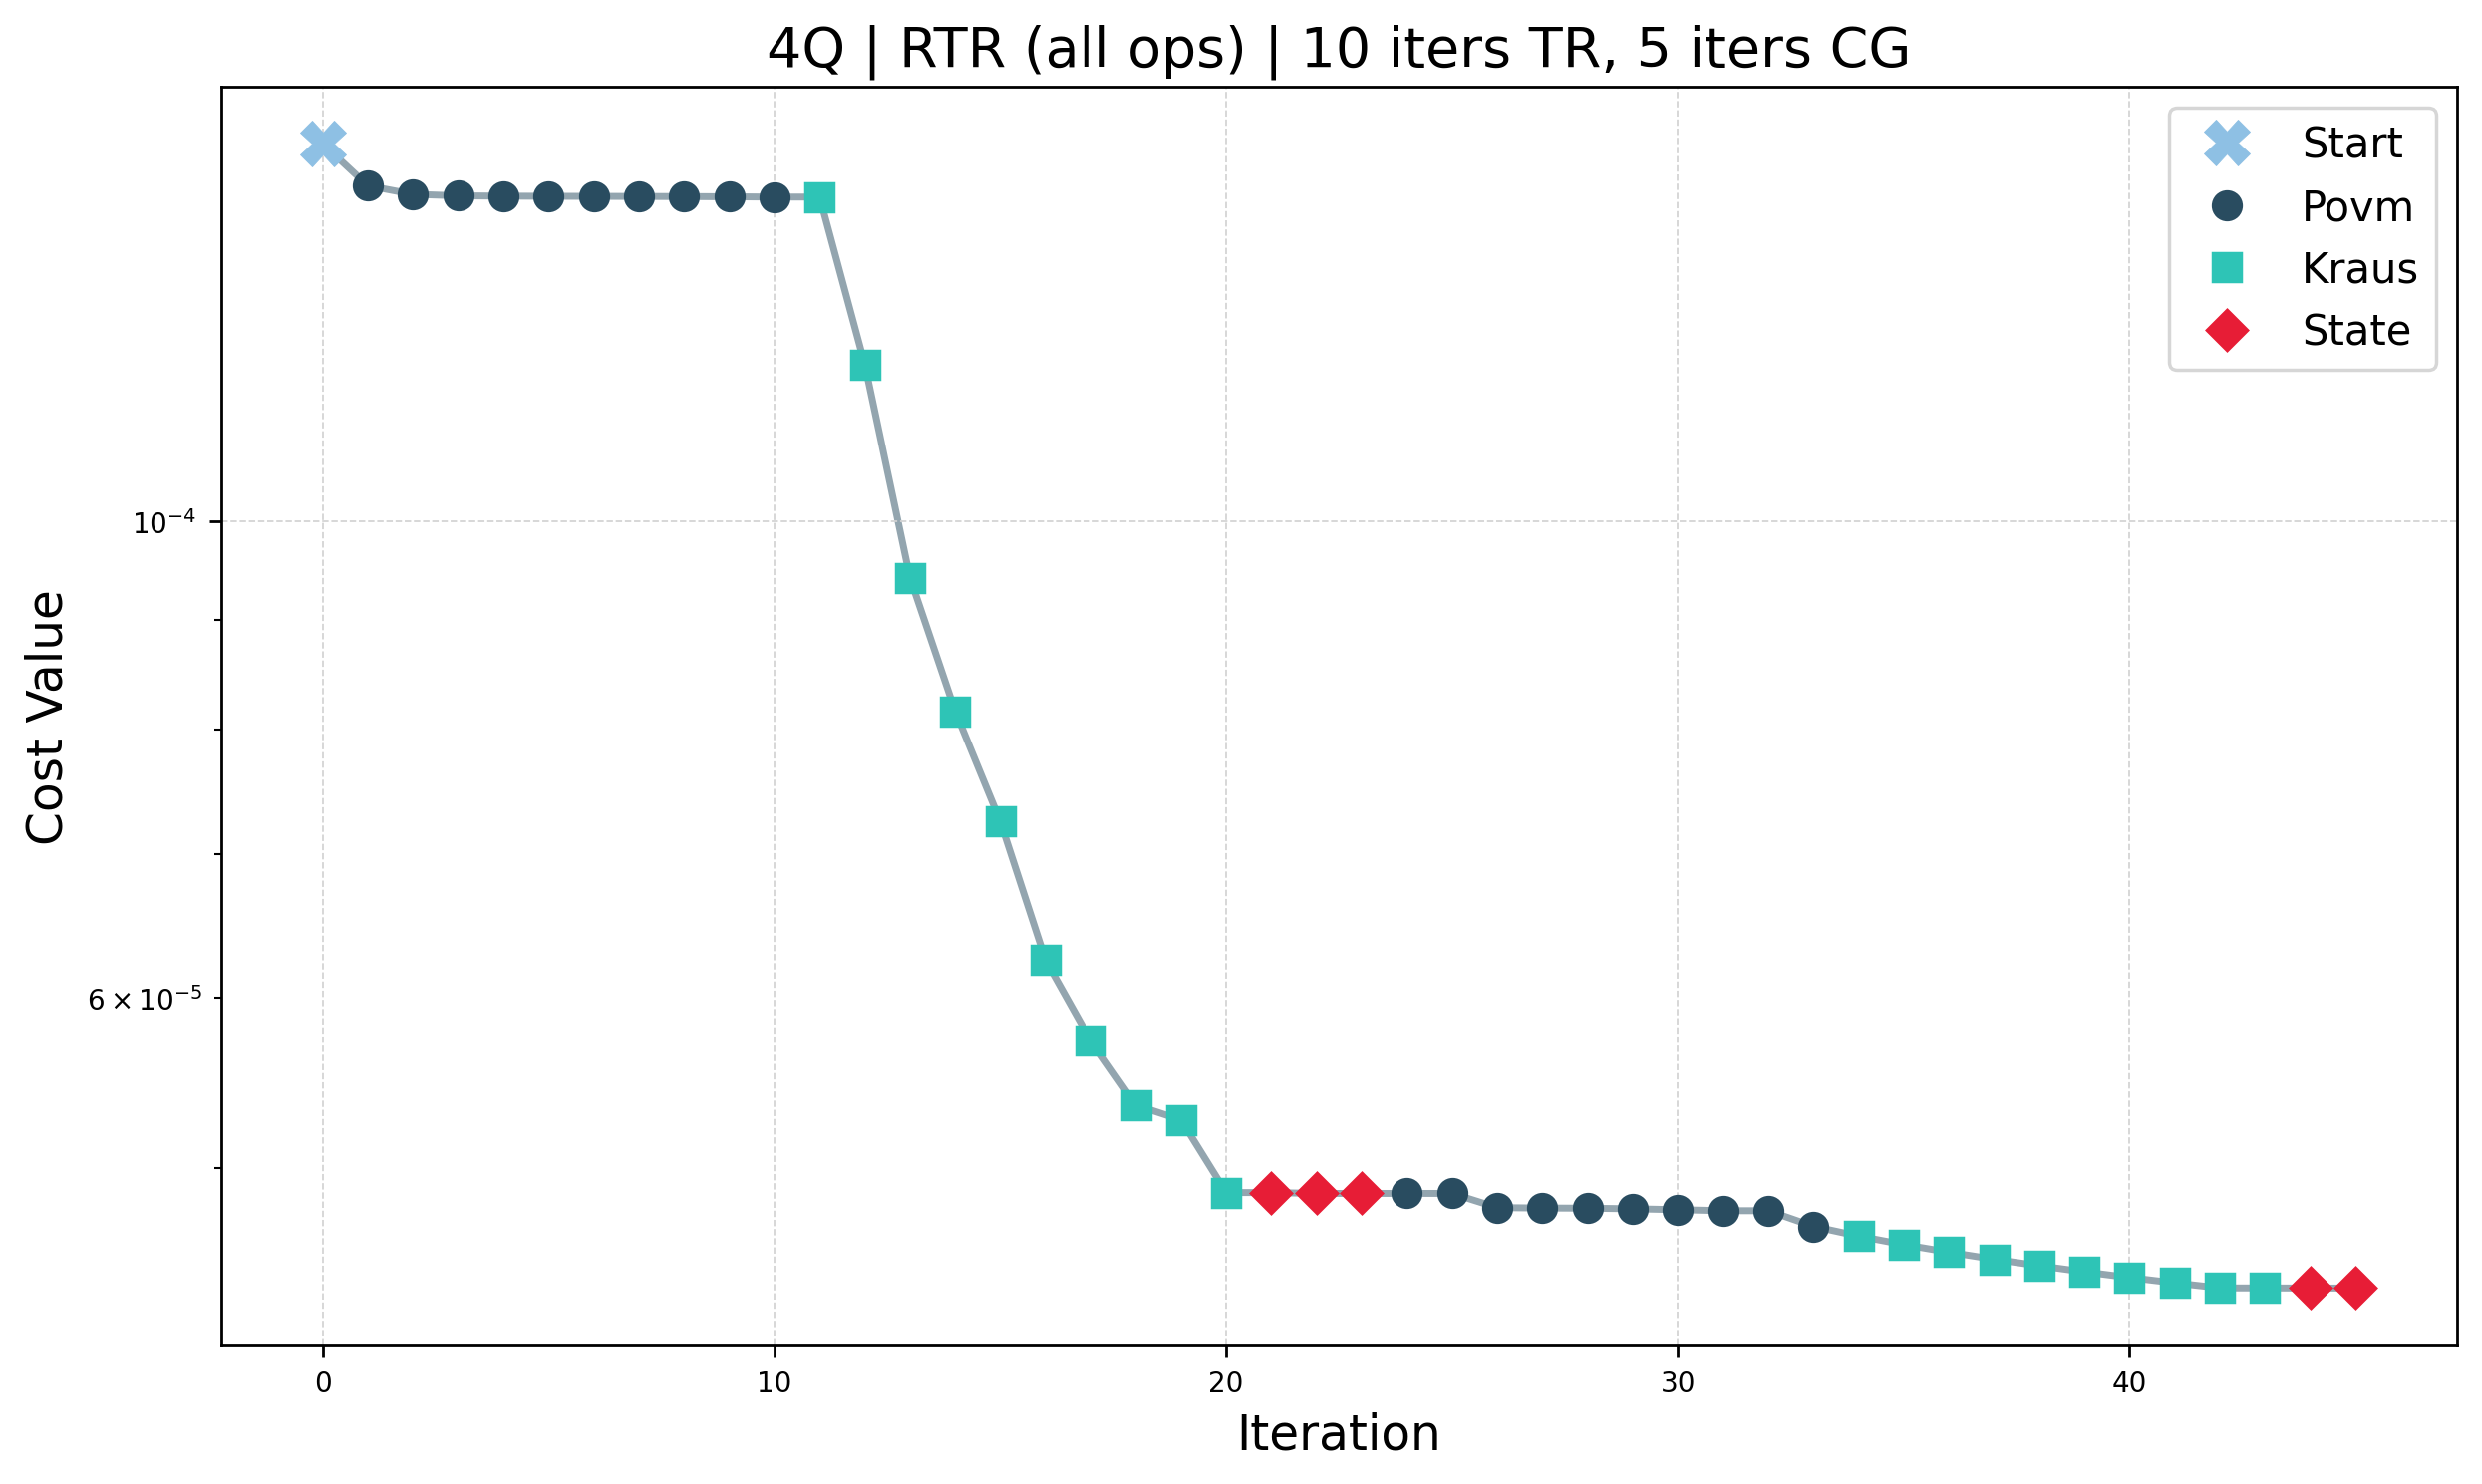

In [45]:
plot_alternating_optimization(
    cost_array=cost_fn_history_all_tr,
    data_operator_map=data_operator_map,
    title="4Q | RTR (all ops) | 10 iters TR, 5 iters CG"
)

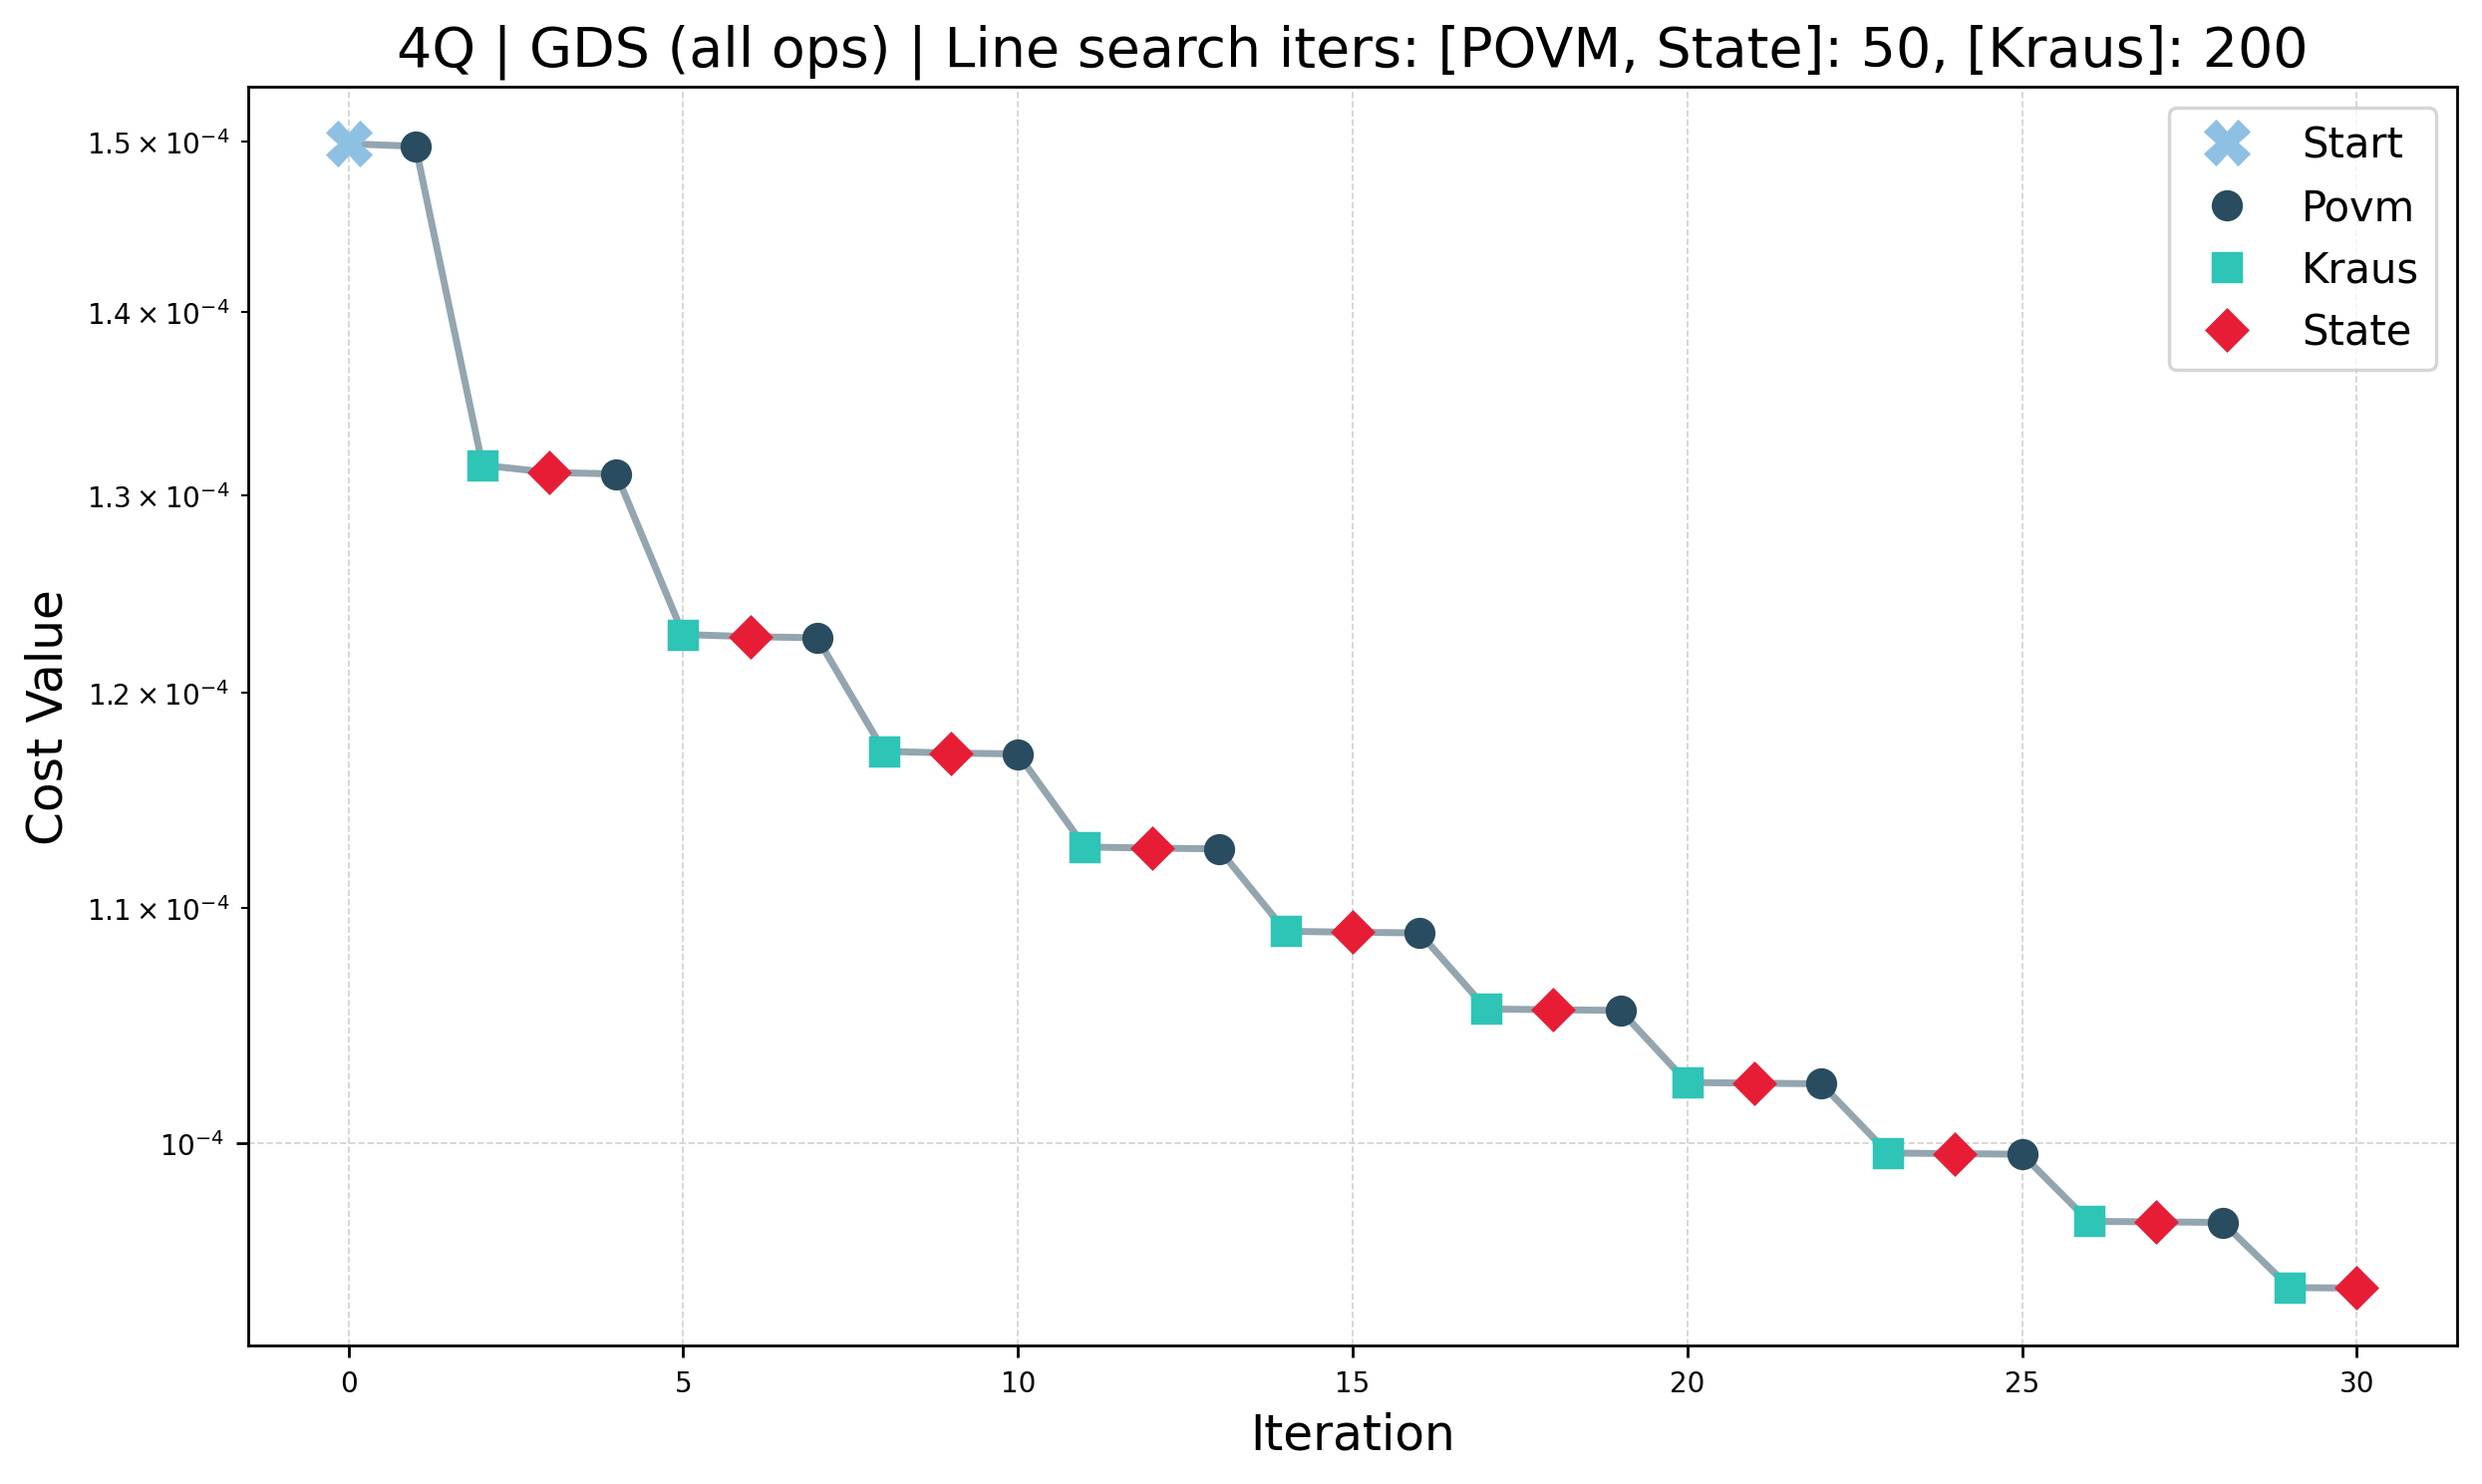

In [46]:
plot_alternating_optimization(
    cost_array=cost_fn_history_all_gds_appended,
    data_operator_map=None,
    title="4Q | GDS (all ops) | Line search iters: [POVM, State]: 50, [Kraus]: 200"
)